# Cosmic Intelligence Lab

Deep Galaxy Explorer — Study 001

Notebook 003 — Open and Inspect the First Hubble FITS Image

# Research Question

What scientific information is contained within a calibrated Hubble FITS image, and how can we inspect it for AI-driven astronomical analysis?

# Objectives

• Open the downloaded FITS file
• Examine the HDUs (Header/Data Units)
• Inspect the FITS header
• Identify important observational metadata
• Prepare the image for visualization

In [1]:
# Cell 2 - Import Required Libraries ===========================

from pathlib import Path

from astropy.io import fits

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Cell 3 - Locate FITS File ====================================

fits_file = Path(
    "../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits"
)

print(f"Exists : {fits_file.exists()}")
print(f"File   : {fits_file.name}")

if fits_file.exists():
    print(f"Size   : {fits_file.stat().st_size:,} bytes")

Exists : True
File   : ib5x1fetq_flt.fits
Size   : 16,608,960 bytes


In [3]:
# Cell 4 - Open FITS File ======================================

hdul = fits.open(fits_file)

print(hdul)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x707247f709b0>, <astropy.io.fits.hdu.image.ImageHDU object at 0x70723f24e090>, <astropy.io.fits.hdu.image.ImageHDU object at 0x70723f298f50>, <astropy.io.fits.hdu.image.ImageHDU object at 0x70723f299a30>, <astropy.io.fits.hdu.image.ImageHDU object at 0x70723f29a420>, <astropy.io.fits.hdu.image.ImageHDU object at 0x70723f29ae10>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f29b4d0>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f29bad0>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f2b0110>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f2b0710>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x70723f2b15b0>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f2b3260>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f2b3860>, <astropy.io.fits.hdu.base.NonstandardExtHDU object at 0x70723f2b3e60>]


In [4]:
# Cell 5 - Inspect HDUs ========================================

hdul.info()

Filename: ../data/raw/mastDownload/HST/ib5x1fetq/ib5x1fetq_flt.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     272   ()      
  1  SCI           1 ImageHDU       207   (1014, 1014)   float32   
  2  ERR           1 ImageHDU        48   (1014, 1014)   float32   
  3  DQ            1 ImageHDU        40   (1014, 1014)   int16   
  4  SAMP          1 ImageHDU        34   (1014, 1014)   int16   
  5  TIME          1 ImageHDU        34   (1014, 1014)   float32   
  6  HDRLET        1 NonstandardExtHDU     17   (5760,)      
  7  HDRLET        2 NonstandardExtHDU     17   (5760,)      
  8  HDRLET        3 NonstandardExtHDU     17   (8640,)      
  9  HDRLET        4 NonstandardExtHDU     17   (8640,)      
 10  WCSCORR       1 BinTableHDU     59   7R x 24C   [40A, I, A, 24A, 24A, 24A, 24A, D, D, D, D, D, D, D, D, 24A, 24A, D, D, D, D, J, 40A, 128A]   
 11  HDRLET        5 NonstandardExtHDU     17   (8640,)      
 12  HDRLET        6 Nons

In [5]:
# Cell 6 - Inspect Primary Header ==============================

header = hdul[0].header

print(header)

SIMPLE  =                    T / file does conform to FITS standard             BITPIX  =                   16 / number of bits per data pixel                  NAXIS   =                    0 / number of data axes                            EXTEND  =                    T / FITS dataset may contain extensions            COMMENT   FITS (Flexible Image Transport System) format is defined in 'AstronomyCOMMENT   and Astrophysics', volume 376, page 359; bibcode: 2001A&A...376..359H ORIGIN  = 'HSTIO/CFITSIO March 2010' / FITS file originator                     DATE    = '2026-06-08' / date this file was written (yyyy-mm-dd)                NEXTEND =                   13 / Number of standard extensions                  FILENAME= 'ib5x1fetq_flt.fits' / name of file                                   FILETYPE= 'SCI      '          / type of data found in data file                                                                                                TELESCOP= 'HST'                / telesco

In [6]:
# Cell 7 - Extract Key Metadata ================================

keys = [
    "TELESCOP",
    "INSTRUME",
    "DETECTOR",
    "FILTER",
    "DATE-OBS",
    "TIME-OBS",
    "EXPTIME",
    "RA_TARG",
    "DEC_TARG",
]

for key in keys:
    print(f"{key:10} : {header.get(key, 'Not Found')}")

TELESCOP   : HST
INSTRUME   : WFC3
DETECTOR   : IR
FILTER     : F160W
DATE-OBS   : 2009-09-06
TIME-OBS   : 06:00:58
EXPTIME    : 1402.936768
RA_TARG    : 53.16041666667
DEC_TARG   : -27.78333333333


In [7]:
# Cell 8 - Inspect Science Image ===============================

science = hdul["SCI"].data

print(type(science))
print(science.shape)
print(science.dtype)

<class 'numpy.ndarray'>
(1014, 1014)
>f4


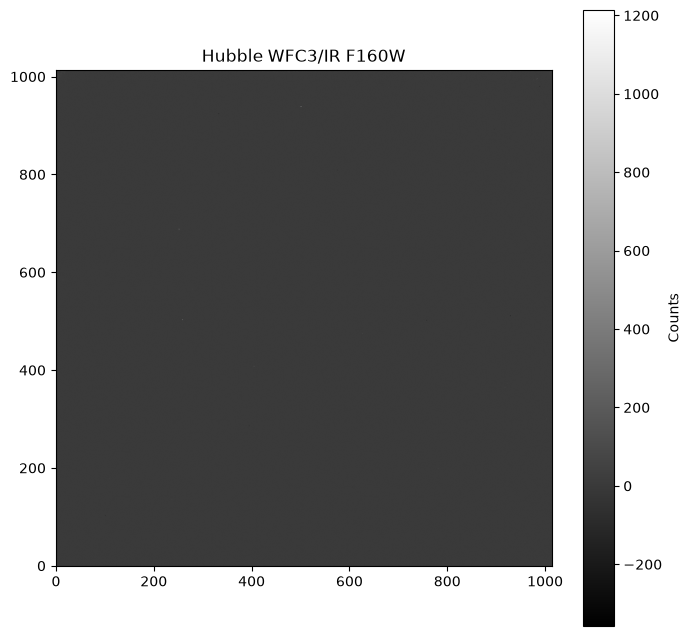

In [8]:
# Cell 9 - Display the Science Image ===========================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray"
)

plt.colorbar(label="Counts")

plt.title("Hubble WFC3/IR F160W")

plt.show()

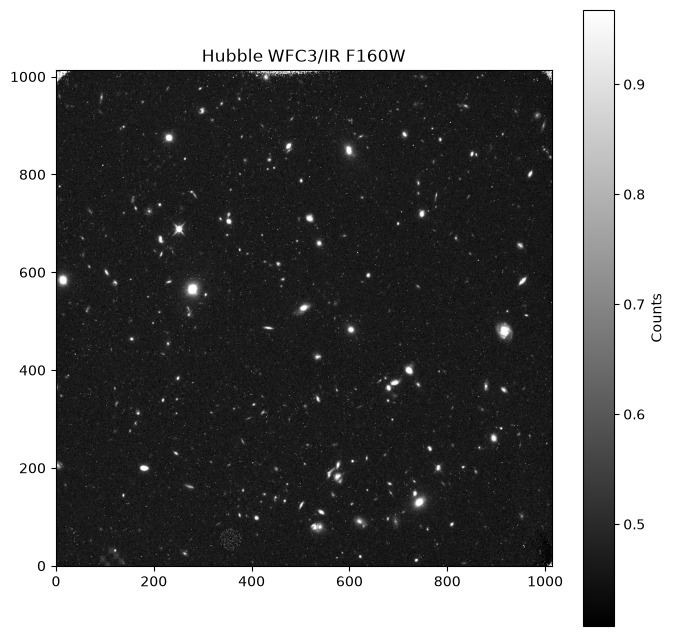

In [9]:
# Cell 10 - Display with Percentile Stretch ====================

import numpy as np
import matplotlib.pyplot as plt

vmin = np.percentile(science, 1)
vmax = np.percentile(science, 99.5)

plt.figure(figsize=(8, 8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="Counts")
plt.title("Hubble WFC3/IR F160W")
plt.show()

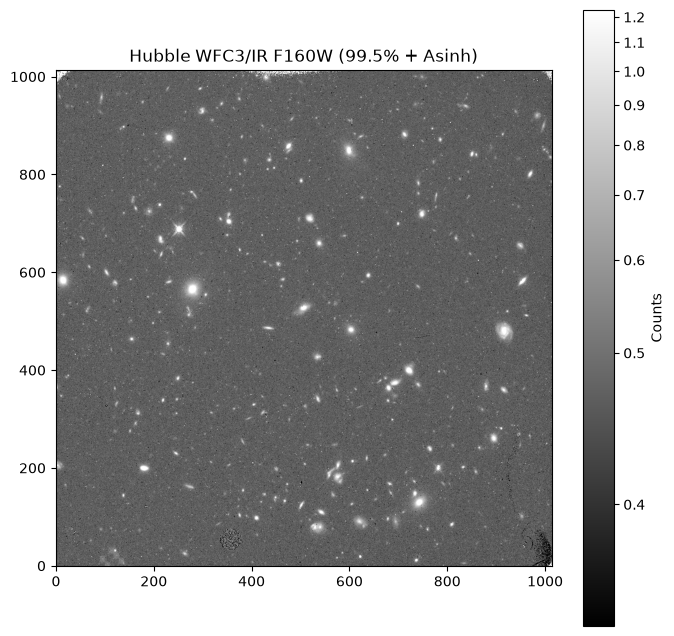

In [10]:
# Cell 11 - Asinh Stretch with Percentile Interval =============

from astropy.visualization import (
    ImageNormalize,
    AsinhStretch,
    PercentileInterval,
)

interval = PercentileInterval(99.3)

norm = ImageNormalize(
    science,
    interval=interval,
    stretch=AsinhStretch()
)

plt.figure(figsize=(8, 8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    norm=norm
)

plt.colorbar(label="Counts")
plt.title("Hubble WFC3/IR F160W (99.5% + Asinh)")

plt.show()

In [11]:
# Cell 12 - Compute Image Statistics ===========================

import numpy as np

print(f"Minimum pixel value : {np.min(science):.2f}")
print(f"Maximum pixel value : {np.max(science):.2f}")
print(f"Mean pixel value    : {np.mean(science):.2f}")
print(f"Median pixel value  : {np.median(science):.2f}")
print(f"Std. deviation      : {np.std(science):.2f}")

Minimum pixel value : -357.44
Maximum pixel value : 1213.84
Mean pixel value    : 0.49
Median pixel value  : 0.47
Std. deviation      : 1.85


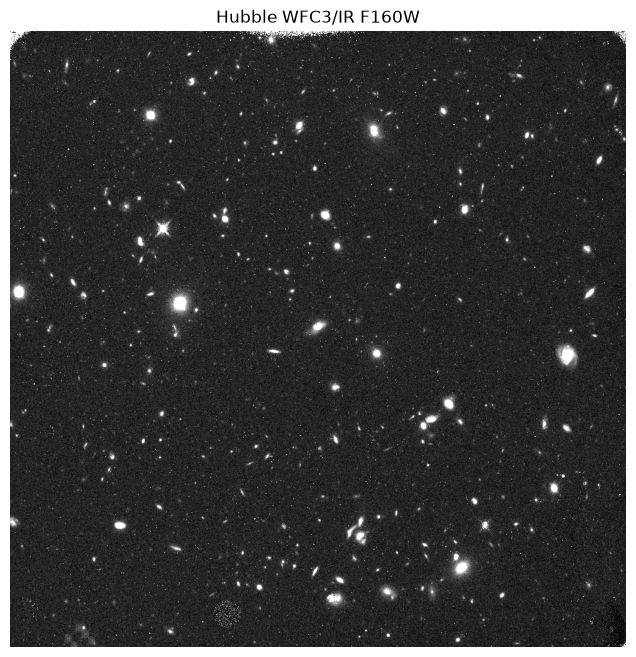

Saved: ../figures/hubble_f160w_first_light.png


In [12]:
# Cell 13 - Save Displayed Image ===============================

from pathlib import Path

figures_dir = Path("../figures")
figures_dir.mkdir(exist_ok=True)

plt.figure(figsize=(8, 8))

plt.imshow(
    science,
    origin="lower",
    cmap="gray",
    vmin=np.percentile(science, 1),
    vmax=np.percentile(science, 99.3)
)

plt.title("Hubble WFC3/IR F160W")
plt.axis("off")

outfile = figures_dir / "hubble_f160w_first_light.png"

plt.savefig(outfile, dpi=300, bbox_inches="tight")

plt.show()

print(f"Saved: {outfile}")

# Scientific Observations

The calibrated FITS image contains a 1014 × 1014 floating-point science image acquired with Hubble's WFC3/IR instrument through the F160W filter. Initial visualization confirms the presence of numerous galaxies, foreground stars, and diffuse background emission. Contrast stretching demonstrates that visualization choices strongly influence the visibility of faint astronomical sources, motivating a systematic comparison of display techniques in Notebook 004.

In [13]:
# Cell 14 - Close FITS File ===================================

hdul.close()

print("FITS file closed successfully.")

FITS file closed successfully.


In [14]:
# Cell 15 - Notebook Status ===================================

from datetime import datetime

print("=" * 60)
print("Notebook Status")
print("=" * 60)

print("Status    : PASS")
print("Notebook  : 03_open_and_inspect_first_hubble_fits_image.ipynb")
print("Completed :", datetime.now().strftime("%Y-%m-%d %H:%M"))

print("\nFirst Hubble FITS image successfully opened and inspected.")
print("Scientific image displayed and saved.")
print("Ready for Notebook 004.")

Notebook Status
Status    : PASS
Notebook  : 03_open_and_inspect_first_hubble_fits_image.ipynb
Completed : 2026-07-30 17:46

First Hubble FITS image successfully opened and inspected.
Scientific image displayed and saved.
Ready for Notebook 004.
